In [1]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#**Task - 1**

In [6]:
#Task 1 — Data Loading & Exploration
print("Task 1 — Data Loading & Exploration")

#Load Dataset
df = pd.read_csv("Housing.csv")

#First 10 Rows
print("\nFirst 10 Rows:")
display(df.head(10))

#Number of Rows and Columns
print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

#Column Names
print("\nColumn Names:")
print(df.columns.tolist())

#Target and Features
target = "price"
features = df.drop("price", axis=1).columns

print("\nTarget Column:")
print(target)

print("\nFeature Columns:")
print(list(features))

#Missing Values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

#Basic Statistics
print("\nStatistical Summary:")
display(df.describe())

print("\nTask 1 Completed Successfully")

Task 1 — Data Loading & Exploration

First 10 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dataset Shape:
Rows: 545
Columns: 13

Column Names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Target Column:
price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values in Each Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Statistical Summary:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



Task 1 Completed Successfully


#**Task - 02**

In [7]:
#Task 2 — Data Cleaning
print("Task 2 — Data Cleaning")

#Checking for the duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

#Removing the duplicates
df=df.drop_duplicates()

#Checking the missing values
print("\nMissing Values Before Handling:")
print(df.isnull().sum())

#Filling the missing values
df = df.fillna(df.median(numeric_only=True))

print("\nMissing Values After Handling:")
print(df.isnull().sum())

#Identify categorical columns
print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

#Convert categorical columns into numeric
df = pd.get_dummies(df, drop_first=True)
print("\nDataset Shape After Encoding:")
print(df.shape)

#Keep meaningful columns
print("\nColumns Before Cleaning:", len(df.columns))
meaningful_columns = df.columns
df = df[meaningful_columns]
print("Columns After Cleaning:", len(df.columns))
print("\nFinal Features:")
print(df.columns.tolist())
print("\nFirst 5 Rows of Cleaned Dataset:")
display(df.head())

print("\nTask 2 Completed Successfully")

Task 2 — Data Cleaning

Number of Duplicate Rows:
0

Missing Values Before Handling:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Missing Values After Handling:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Categorical Columns:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Dataset Shape After Encoding:
(545, 14)

Columns Before Cleaning: 14
Columns After Cleaning: 14

Final Features:
['price', 'area', 'bedrooms', 'bathrooms'

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False



Task 2 Completed Successfully


#**Task 3 — Model Building**

In [8]:
#Task 3 — Model Building
print("Task 3 — Model Building")

#Define Features and Target
X = df.drop("price", axis=1)
y = df["price"]
print("\nFeature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

#Split Dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("\nTraining Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

#Linear Regression Model

print("\n----- Linear Regression -----")
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

#Random Forest Regressor

print("\n----- Random Forest Regressor -----")
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

#Model Comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})
print("\nModel Comparison:")
display(comparison)

#Best Model
best_model = comparison.loc[comparison["R² Score"].idxmax(), "Model"]
print("\nBest Performing Model:", best_model)
print("\nTask 3 Completed Successfully")

Task 3 — Model Building

Feature Matrix Shape: (545, 13)
Target Variable Shape: (545,)

Training Set Size: 436
Testing Set Size: 109

----- Linear Regression -----
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184

----- Random Forest Regressor -----
MAE : 1013968.579587156
RMSE: 1398115.6668385956
R² Score: 0.6132752494107068

Model Comparison:


,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275



Best Performing Model: Linear Regression

Task 3 Completed Successfully


#**Task 4 — Visualization**

Task 4 — Visualization


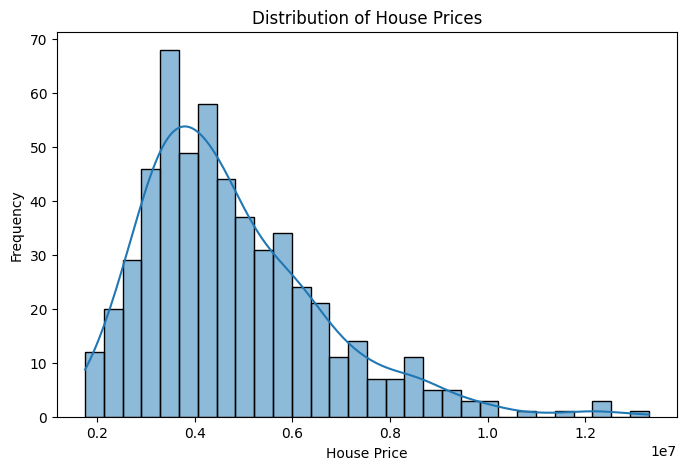

Chart 1 Completed: House Price Distribution


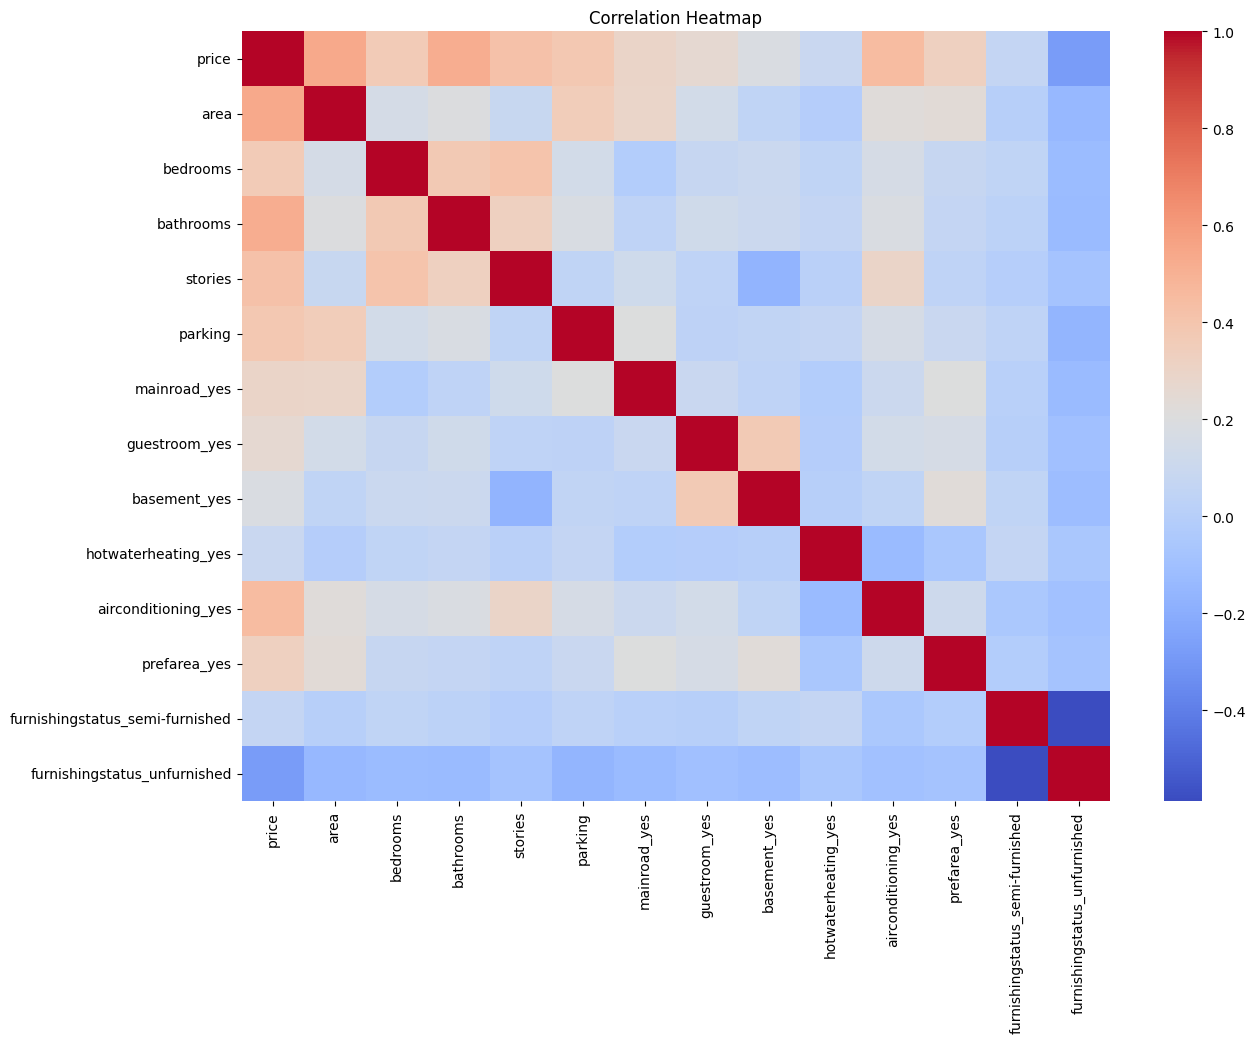

Chart 2 Completed: Correlation Heatmap


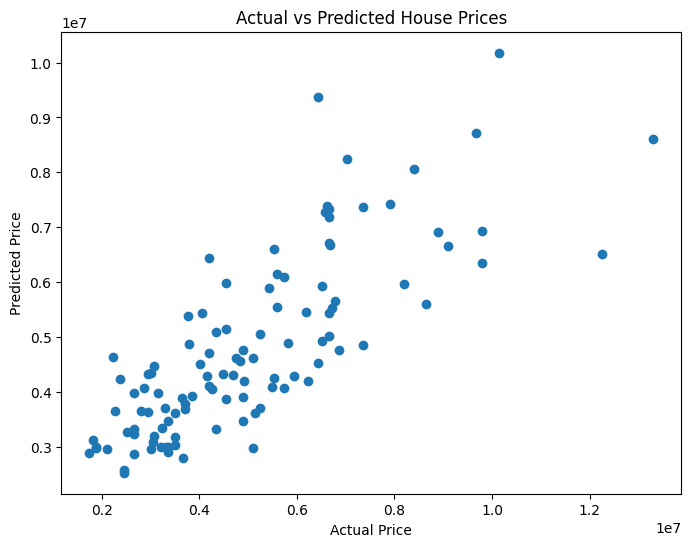

Chart 3 Completed: Actual vs Predicted Prices

All Charts Generated Successfully
Images Saved:
1. price_distribution.png
2. correlation_heatmap.png
3. actual_vs_predicted.png

Task 4 Completed Successfully


In [9]:
#Task 4 — Visualization
print("Task 4 — Visualization")

#Chart 1: House Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.savefig("price_distribution.png")
plt.show()
print("Chart 1 Completed: House Price Distribution")

#Chart 2: Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),cmap="coolwarm",annot=False)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()
print("Chart 2 Completed: Correlation Heatmap")

#Chart 3: Actual vs Predicted Price
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.savefig("actual_vs_predicted.png")
plt.show()

print("Chart 3 Completed: Actual vs Predicted Prices")
print("\nAll Charts Generated Successfully")
print("Images Saved:")
print("1. price_distribution.png")
print("2. correlation_heatmap.png")
print("3. actual_vs_predicted.png")
print("\nTask 4 Completed Successfully")

# Task 5 — Insights & Summary

### Key Findings

**1. Features Influencing House Price**

* House area was the most influential feature affecting price.
* The number of bathrooms, stories, and parking spaces also showed a strong positive relationship with house price.
* Additional amenities such as air conditioning, preferred area location, and furnishing status contributed significantly to higher property values.

**2. Model Performance**

* Two regression models were trained and evaluated: Linear Regression and Random Forest Regressor.
* Linear Regression achieved the best performance with an R² Score of approximately **0.65**, outperforming Random Forest on this dataset.
* This indicates that the model was able to explain about **65% of the variation** in house prices, providing reasonably accurate predictions.

**3. Interesting Observations**

* The distribution of house prices was right-skewed, meaning a small number of properties were significantly more expensive than the majority.
* Categorical features such as furnishing status and preferred area had a noticeable impact on pricing despite not being physical property characteristics.
* No missing values or duplicate records were found in the dataset, resulting in a clean dataset for analysis.

**4. Business Recommendation**

* Real estate businesses should focus on highlighting larger properties with modern amenities such as multiple bathrooms, parking facilities, and air conditioning.
* Properties located in preferred areas and offered in furnished or semi-furnished condition may attract higher market prices and increased buyer interest.

### Conclusion

The project successfully developed a house price prediction model and identified the major factors influencing property value. Among the evaluated models, Linear Regression delivered the best results and provided reliable price predictions for this dataset. The analysis demonstrates how data-driven approaches can assist real estate businesses in making informed pricing and marketing decisions.
